In [1]:
# !pip install -r ../requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

dataset = load_dataset('IlyaGusev/gazeta', revision='v2.0')
for split in dataset.keys():
    print(f"  {split}: {len(dataset[split])} примеров")

/Users/gab1k/Desktop/hse-llm/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using the latest cached version of the dataset since IlyaGusev/gazeta couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/gab1k/.cache/huggingface/datasets/IlyaGusev___gazeta/default/2.0.0/c329f0fc1c22ab6e43e0045ee659d0d43c647492baa2a6ab3a5ea7dac98cd552 (last modified on Sun Feb 15 14:12:51 2026).


  train: 60964 примеров
  test: 6793 примеров
  validation: 6369 примеров


### Сэмпл из train'а

In [3]:
dataset['train'][0]

{'text': 'Сегодня транспортный налог начисляется в зависимости от мощности автомобиля, причем цена для «сильных» машин выше, чем для малолитражек. Также ставку налога могут корректировать региональные власти: согласно Налоговому кодексу, базовый тариф, установленный правительством, может быть уменьшен в пять раз или увеличен до 10 раз. Сборы идут в региональные бюджеты, откуда растекаются на общие нужды. Транспортный налог — один из основных источников бюджетных доходов — предлагается направить исключительно на дорожные фонды. Так, автомобилисты будут понимать, за что они платят, а дорожники будут иметь гарантированный доход. Кроме налога дорожные фонды будут пополняться за счет бюджетных средств и проезда по платным дорогам. Более того, транспортный налог предлагается завуалировать в акцизы на бензин. Привычную и раздражающую систему ежегодной оплаты квитанции предлагается изменить, включив налог в стоимость топлива. Минэкономразвития говорит об удвоении акцизы, которая сегодня состав

### Числовые статистики

In [4]:
def calculate_stats(split_data, split_name):
    
    text_lengths = []
    summary_lengths = []
    text_words = []
    summary_words = []
    text_sentences = []
    summary_sentences = []
    compression_ratios = []
    
    for item in split_data:
        text = item['text']
        summary = item['summary']
        
        text_lengths.append(len(text))
        summary_lengths.append(len(summary))
        
        text_word_count = len(text.split())
        summary_word_count = len(summary.split())
        text_words.append(text_word_count)
        summary_words.append(summary_word_count)
        
        text_sentences.append(text.count('.') + text.count('!') + text.count('?'))
        summary_sentences.append(summary.count('.') + summary.count('!') + summary.count('?'))
        
        if text_word_count > 0:
            compression_ratios.append(summary_word_count / text_word_count)
    
    stats = {
        'split': split_name,
        'count': len(split_data),
        'text_chars_mean': np.mean(text_lengths),
        'summary_chars_mean': np.mean(summary_lengths),
        'text_words_mean': np.mean(text_words),
        'summary_words_mean': np.mean(summary_words),
        'text_sentences_mean': np.mean(text_sentences),
        'summary_sentences_mean': np.mean(summary_sentences),
        'compression_ratio_mean': np.mean(compression_ratios)
    }
    
    return stats, {
        'text_lengths': text_lengths,
        'summary_lengths': summary_lengths,
        'text_words': text_words,
        'summary_words': summary_words,
        'compression_ratios': compression_ratios
    }

train_stats, train_distributions = calculate_stats(dataset['train'], 'train')
val_stats, val_distributions = calculate_stats(dataset['validation'], 'validation')
test_stats, test_distributions = calculate_stats(dataset['test'], 'test')

stats_df = pd.DataFrame([train_stats, val_stats, test_stats])
stats_df

,split,count,text_chars_mean,summary_chars_mean,text_words_mean,summary_words_mean,text_sentences_mean,summary_sentences_mean,compression_ratio_mean
0,train,60964,4525.268831,310.945804,632.772538,41.940818,39.985237,2.745752,0.069919
1,validation,6369,4358.404773,335.571832,603.997959,45.616580,37.518763,2.918669,0.079422
2,test,6793,4446.085235,343.419108,609.981304,46.348300,37.188576,2.969086,0.080723


### Визуализация распределений длин текстов

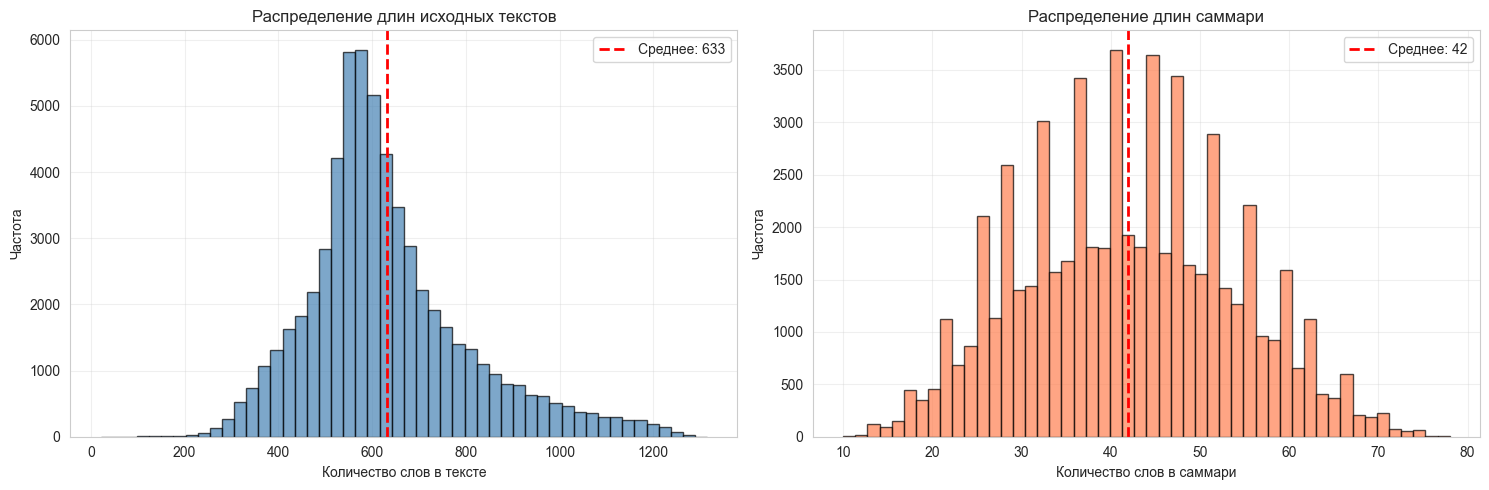

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(train_distributions['text_words'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(train_stats['text_words_mean'], color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {train_stats["text_words_mean"]:.0f}')
axes[0].set_xlabel('Количество слов в тексте')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение длин исходных текстов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(train_distributions['summary_words'], bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(train_stats['summary_words_mean'], color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {train_stats["summary_words_mean"]:.0f}')
axes[1].set_xlabel('Количество слов в саммари')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение длин саммари')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()